# Avaliação Intermediária: Quanto custa um alerta?

Dupla: Felipe Sarian; Pedro Henrique · código `025bc8` · random_state `39569455` · classe difícil `Bot`

In [1]:
import os
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, recall_score)

RS = 39569455
CODIGO = '025bc8'
CLASSE_DIFICIL = 'Bot'
COR_BENIGN, COR_ATAQUE = '#2a78d6', '#eb6834'
# o dataset do Roteiro 2: copia no proprio repo ou a pasta do R2 ao lado
ARQ_R2 = next(p for p in [f'R2_{CODIGO}.csv.gz',
                          f'../roteiro2/roteiro2_dados/dados/R2_{CODIGO}.csv.gz',
                          f'../Roteiro 02/roteiro2_dados/dados/R2_{CODIGO}.csv.gz']
              if os.path.exists(p))

---

## a) Reconstruir o modelo e salvá-lo

In [2]:
flx = pd.read_csv(ARQ_R2, encoding='latin-1', low_memory=False)
flx.columns = flx.columns.str.strip()
contexto = ['Label', 'ordem_captura', 'dia', 'turno']
flx.shape

(111679, 83)

In [3]:
def limpar(flx):
    # mesma limpeza do item e) do Roteiro 2
    numericas = [c for c in flx.columns if c not in contexto]
    constantes = [c for c in numericas if flx[c].nunique(dropna=False) <= 1]
    visto, identicas = {}, []
    for c in [x for x in numericas if x not in constantes]:
        k = pd.util.hash_pandas_object(flx[c].round(6), index=False).values.tobytes()
        if k in visto:
            identicas.append(c)
        else:
            visto[k] = c
    features = [c for c in flx.columns if c not in contexto + ['alertas_ids']]

    log = []
    def registra(passo, antes, df):
        log.append({'passo': passo, 'linhas': len(df),
                    'removidas': antes - len(df), 'colunas': df.shape[1]})

    limpo = flx.drop(columns=['alertas_ids'])
    registra('remove alertas_ids', len(flx), limpo)

    n = len(limpo)
    limpo[features] = limpo[features].replace([np.inf, -np.inf], np.nan)
    limpo = limpo.dropna(subset=features)
    registra('Infinity e NaN', n, limpo)

    limpo = limpo.drop(columns=constantes + identicas)
    feats = [c for c in features if c in limpo.columns]
    registra('constantes e duplicadas', len(limpo), limpo)

    n = len(limpo)
    k = pd.util.hash_pandas_object(limpo[feats], index=False)
    limpo = limpo[limpo.groupby(k)['Label'].transform('nunique') == 1]
    registra('rótulos conflitantes', n, limpo)

    n = len(limpo)
    limpo = limpo.drop_duplicates(subset=feats)
    registra('duplicatas nas features', n, limpo)

    n = len(limpo)
    limpo = limpo[~limpo[feats].round(3).duplicated()]
    registra('cópias com jitter', n, limpo)

    return limpo, feats, pd.DataFrame(log)


flx_limpo, features_limpas, log = limpar(flx)
assert 'alertas_ids' not in flx_limpo.columns
print(log.to_string(index=False))
print('forma final:', flx_limpo.shape, '|', len(features_limpas), 'features')

                  passo  linhas  removidas  colunas
     remove alertas_ids  111679          0       82
         Infinity e NaN  111569        110       82
constantes e duplicadas  111569          0       66
   rótulos conflitantes  111242        327       66
duplicatas nas features  105243       5999       66
      cópias com jitter  105097        146       66
forma final: (105097, 66) | 62 features


In [4]:
flx_limpo['ataque'] = (flx_limpo['Label'] != 'BENIGN').astype(int)

# split temporal: primeiros 70% da ordem_captura treinam, dentro de cada (dia, Label)
pos = flx_limpo.groupby(['dia', 'Label'])['ordem_captura'].rank(method='first', pct=True)
treino = pos <= 0.70

X_tr, y_tr = flx_limpo.loc[treino, features_limpas], flx_limpo.loc[treino, 'ataque']
X_te, y_te = flx_limpo.loc[~treino, features_limpas], flx_limpo.loc[~treino, 'ataque']
label_te = flx_limpo.loc[~treino, 'Label']

pd.DataFrame({'linhas': [len(X_tr), len(X_te)],
              'ataques': [y_tr.sum(), y_te.sum()],
              'prevalencia_ataque': [y_tr.mean(), y_te.mean()]},
             index=['treino', 'teste']).round(4)

,linhas,ataques,prevalencia_ataque
treino,73556,29564,0.4019
teste,31541,12684,0.4021


In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=RS, n_jobs=-1)
rf.fit(X_tr, y_tr)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
os.makedirs('saida', exist_ok=True)
arq_rf = f'saida/avaliacao_{CODIGO}_rf.joblib'
arq_teste = f'saida/avaliacao_{CODIGO}_teste.csv.gz'

joblib.dump(rf, arq_rf)
teste = X_te.assign(ataque=y_te, Label=label_te)
teste.to_csv(arq_teste, index=False)

# conferência dos arquivos salvos
rf_lido = joblib.load(arq_rf)
teste_lido = pd.read_csv(arq_teste)
assert list(rf_lido.feature_names_in_) == list(teste_lido.columns[:-2])
for arq in [arq_rf, arq_teste]:
    print(f'{arq}  {os.path.getsize(arq) / 1e6:.1f} MB')
print('teste salvo:', teste_lido.shape)

saida/avaliacao_025bc8_rf.joblib  10.6 MB
saida/avaliacao_025bc8_teste.csv.gz  2.7 MB
teste salvo: (31541, 64)


---

## b) Da classe à probabilidade

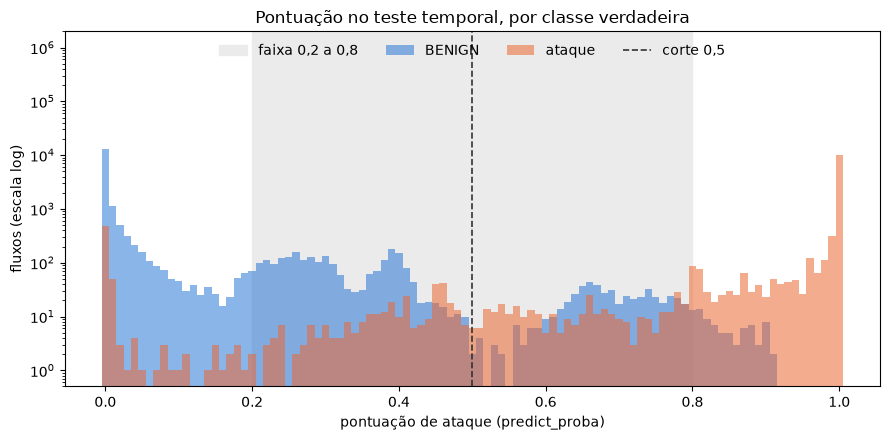

In [7]:
p_te = rf.predict_proba(X_te)[:, 1]

# com 100 árvores a pontuação anda em passos de 0,01: um bin por valor possível
bins = np.linspace(-0.005, 1.005, 102)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvspan(0.2, 0.8, color='0.92', zorder=0, label='faixa 0,2 a 0,8')
for classe, nome, cor in [(0, 'BENIGN', COR_BENIGN), (1, 'ataque', COR_ATAQUE)]:
    ax.hist(p_te[y_te.values == classe], bins=bins, histtype='stepfilled',
            alpha=0.55, color=cor, label=nome)
ax.axvline(0.5, color='0.2', linestyle='--', linewidth=1.2, label='corte 0,5')
ax.set_yscale('log')
ax.set_ylim(0.5, 2e6)
ax.set_xlabel('pontuação de ataque (predict_proba)')
ax.set_ylabel('fluxos (escala log)')
ax.set_title('Pontuação no teste temporal, por classe verdadeira')
ax.legend(loc='upper center', ncol=4, frameon=False)
plt.tight_layout()
plt.show()

In [8]:
faixas = {'p < 0,2': p_te < 0.2,
          '0,2 <= p <= 0,8': (p_te >= 0.2) & (p_te <= 0.8),
          'p > 0,8': p_te > 0.8,
          '0,45 <= p <= 0,55': (p_te >= 0.45) & (p_te <= 0.55)}
eh_ataque = y_te.values == 1
pd.DataFrame({nome: [(m & ~eh_ataque).sum(), (m & eh_ataque).sum(), m.sum()]
              for nome, m in faixas.items()},
             index=['BENIGN', 'ataque', 'total'])

,"p < 0,2","0,2 <= p <= 0,8","p > 0,8","0,45 <= p <= 0,55"
BENIGN,15963,2825,69,75
ataque,550,723,11411,186
total,16513,3548,11480,261


### Pergunta B.1

Os fluxos em que o modelo tem dúvida estão entre 0,2 e 0,8: são 3.548 fluxos, cerca de 11% do teste, sendo 2.825 benignos e 723 ataques. A maior parte do teste fica nos extremos, com 16.513 fluxos abaixo de 0,2 e 11.480 acima de 0,8. Mesmo em escala log, porém, a faixa do meio está longe de vazia. O tráfego benigno duvidoso forma um volume de algumas centenas de fluxos por valor de pontuação entre 0,2 e 0,45 e um segundo volume, de algumas dezenas, entre 0,55 e 0,8, enquanto os ataques se espalham por toda a faixa.

O corte 0,5 passa por uma região povoada. Ele cai num vale entre os dois volumes, mas ainda há 261 fluxos entre 0,45 e 0,55 (75 benignos e 186 ataques), de modo que qualquer deslocamento do limiar move dezenas de fluxos de um lado para o outro da matriz de confusão. O histograma também mostra 550 ataques com pontuação abaixo de 0,2, erros cometidos com convicção que nenhum ajuste fino em torno de 0,5 recupera.

---

## c) ROC contra Precision-Recall

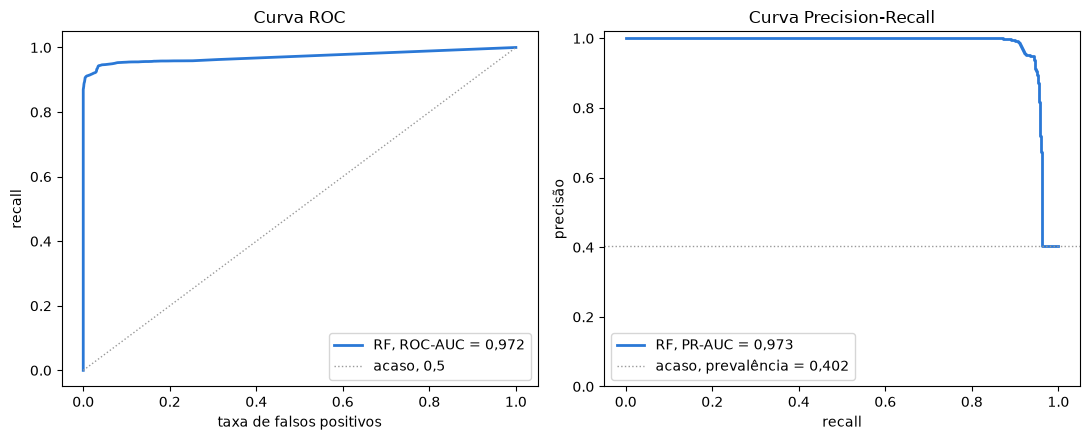

ROC-AUC 0.9721 | PR-AUC 0.9731 | prevalência de ataque no teste 0.4021


In [9]:
roc_auc = roc_auc_score(y_te, p_te)
pr_auc = average_precision_score(y_te, p_te)
prevalencia = y_te.mean()
fpr, tpr, _ = roc_curve(y_te, p_te)
precisao, revocacao, _ = precision_recall_curve(y_te, p_te)
br = lambda x: f'{x:.3f}'.replace('.', ',')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(fpr, tpr, color=COR_BENIGN, linewidth=2, label=f'RF, ROC-AUC = {br(roc_auc)}')
ax1.plot([0, 1], [0, 1], color='0.6', linestyle=':', linewidth=1, label='acaso, 0,5')
ax1.set_xlabel('taxa de falsos positivos')
ax1.set_ylabel('recall')
ax1.set_title('Curva ROC')
ax1.legend(loc='lower right')

ax2.step(revocacao, precisao, where='post', color=COR_BENIGN, linewidth=2,
         label=f'RF, PR-AUC = {br(pr_auc)}')
ax2.axhline(prevalencia, color='0.6', linestyle=':', linewidth=1,
            label=f'acaso, prevalência = {br(prevalencia)}')
ax2.set_xlabel('recall')
ax2.set_ylabel('precisão')
ax2.set_ylim(0, 1.02)
ax2.set_title('Curva Precision-Recall')
ax2.legend(loc='lower left')
plt.tight_layout()
plt.show()

print(f'ROC-AUC {roc_auc:.4f} | PR-AUC {pr_auc:.4f} | prevalência de ataque no teste {prevalencia:.4f}')

In [10]:
pred05 = (p_te >= 0.5).astype(int)
eh_bot = (label_te == CLASSE_DIFICIL).values

display(pd.DataFrame({'fluxos': [int(y_te.sum()), int(eh_bot.sum())],
                      'recall no corte 0,5': [recall_score(y_te, pred05), pred05[eh_bot].mean()]},
                     index=['ataque (global)', CLASSE_DIFICIL]).round(4))

print(f'{CLASSE_DIFICIL} com pontuação 0: {(p_te[eh_bot] == 0).mean():.1%}')
print(f'recall de {CLASSE_DIFICIL} mesmo no corte 0,05: {(p_te[eh_bot] >= 0.05).mean():.4f}')

,fluxos,"recall no corte 0,5"
ataque (global),12684,0.9332
Bot,592,0.1554


Bot com pontuação 0: 75.8%
recall de Bot mesmo no corte 0,05: 0.1605


### Pergunta C.1

Neste teste as duas áreas contam a mesma história: ROC-AUC de 0,972 e PR-AUC de 0,973. Isso acontece porque aqui o ataque não é uma classe rara, já que 40,2% do teste é ataque, e a curva ROC só esconde falsos positivos quando os negativos são muito mais numerosos que os positivos. As referências de acaso, no entanto, são diferentes: 0,5 para a ROC e 0,402 para a PR. As duas curvas mostram também o mesmo defeito: a precisão se mantém perto de 1 até um recall próximo de 0,9, e os últimos ataques só são alcançados quando a precisão desaba para o nível do acaso, porque esses ataques recebem pontuação 0.

Para a reunião com o gestor do SOC eu levaria a PR-AUC. A precisão tem o número de alertas no denominador e responde diretamente à pergunta do analista sobre quantos dos alertas da fila valem a pena. Além disso, em produção a proporção de ataques será muito menor que os 40% deste recorte, e nessa situação a ROC continuaria parecendo excelente enquanto a precisão caísse, que é a falácia da taxa-base.

### Pergunta C.2

Não é compatível. No corte 0,5 o recall global é 0,933, mas o recall do Bot é apenas 0,155: dos 592 fluxos de Bot no teste, a grande maioria passa sem alerta. O número global é dominado pelas classes volumosas e fáceis, e os 592 fluxos de Bot são menos de 5% dos 12.684 ataques do teste, pouco para mover a média.

Isso mostra que um único limiar para todas as classes esconde as classes difíceis. No caso do Bot, o limiar nem é a alavanca certa: 75,8% dos fluxos recebem pontuação 0, e mesmo com o corte em 0,05 o recall sobe só para 0,161, enquanto o volume de alertas falsos cresceria para todo o tráfego. O problema está na mudança de comportamento da campanha observada no Roteiro 2, não no ponto de corte. Por isso o desempenho precisa ser acompanhado por classe, e classes como o Bot pedem tratamento próprio, com features ou modelos específicos, em vez de um ajuste do limiar global.

---

## d) Varredura de limiar

In [11]:
def varrer_limiares(y, p, limiares, custo_fp=None, custo_fn=None):
    """Métricas de cada limiar; o corte t significa p >= t.

    custo_fp e custo_fn aceitam um escalar ou um vetor com um valor por linha,
    de modo que a mesma função serve ao custo fixo do item e) e ao custo por
    transação do item h).
    """
    y = np.asarray(y).astype(bool)
    p = np.asarray(p, dtype=float)
    com_custo = custo_fp is not None or custo_fn is not None
    zero = 0.0
    c_fp = np.broadcast_to(np.asarray(zero if custo_fp is None else custo_fp, dtype=float), y.shape)
    c_fn = np.broadcast_to(np.asarray(zero if custo_fn is None else custo_fn, dtype=float), y.shape)

    linhas = []
    for t in limiares:
        alerta = p >= t
        m_tp, m_fp, m_fn = alerta & y, alerta & ~y, ~alerta & y
        tp, fp, fn = int(m_tp.sum()), int(m_fp.sum()), int(m_fn.sum())
        precisao = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precisao * recall / (precisao + recall) if precisao + recall else 0.0
        linha = {'limiar': t, 'TP': tp, 'FP': fp, 'FN': fn, 'alertas': tp + fp,
                 'precisao': precisao, 'recall': recall, 'F1': f1}
        if com_custo:
            linha['custo_fp'] = float(c_fp[m_fp].sum())
            linha['custo_fn'] = float(c_fn[m_fn].sum())
            linha['custo_total'] = linha['custo_fp'] + linha['custo_fn']
        linhas.append(linha)
    return pd.DataFrame(linhas)


LIMIARES = np.round(np.arange(0.05, 1.0, 0.05), 2)
tab_d = varrer_limiares(y_te, p_te, LIMIARES)
display(tab_d.round(4))

,limiar,TP,FP,FN,alertas,precisao,recall,F1
0,0.05,12154,3721,530,15875,0.7656,0.9582,0.8512
1,0.10,12148,3247,536,15395,0.7891,0.9577,0.8653
2,0.15,12144,3074,540,15218,0.7980,0.9574,0.8705
3,0.20,12134,2894,550,15028,0.8074,0.9566,0.8757
4,0.25,12118,2399,566,14517,0.8347,0.9554,0.8910
5,0.30,12102,1768,582,13870,0.8725,0.9541,0.9115
6,0.35,12074,1420,610,13494,0.8948,0.9519,0.9225
7,0.40,12013,971,671,12984,0.9252,0.9471,0.9360
8,0.45,11957,656,727,12613,0.9480,0.9427,0.9453
9,0.50,11837,592,847,12429,0.9524,0.9332,0.9427


In [12]:
i_f1 = tab_d['F1'].idxmax()
t_f1 = tab_d.loc[i_f1, 'limiar']
em_f1, em_05 = tab_d.loc[i_f1], tab_d.loc[tab_d['limiar'] == 0.5].iloc[0]

display(tab_d[tab_d['limiar'].isin([0.5, t_f1])].round(4))
print(f'F1 máximo no limiar {t_f1:.2f}: {em_f1.F1:.4f} contra {em_05.F1:.4f} no corte 0,5')
print(f'falsos positivos: {int(em_f1.FP)} contra {int(em_05.FP)}, '
      f'{int(em_05.FP - em_f1.FP)} a menos')
print(f'falsos negativos: {int(em_f1.FN)} contra {int(em_05.FN)}, '
      f'{int(em_f1.FN - em_05.FN)} a mais')
print(f'alertas no período: {int(em_f1.alertas)} contra {int(em_05.alertas)}')

,limiar,TP,FP,FN,alertas,precisao,recall,F1
9,0.5,11837,592,847,12429,0.9524,0.9332,0.9427
15,0.8,11498,82,1186,11580,0.9929,0.9065,0.9477


F1 máximo no limiar 0.80: 0.9477 contra 0.9427 no corte 0,5
falsos positivos: 82 contra 592, 510 a menos
falsos negativos: 1186 contra 847, 339 a mais
alertas no período: 11580 contra 12429


### Pergunta D.1

O F1 máximo está no limiar 0,80, com 0,9477 contra 0,9427 do corte 0,5. A curva do F1 não é monótona: há um máximo local em 0,45, com 0,9453, um vale em 0,60, com 0,9390, e o máximo global em 0,80.

Em relação ao corte 0,5, o limiar de 0,80 produz 510 falsos positivos a menos, 82 contra 592. Em troca, deixa passar 339 ataques a mais, 1.186 contra 847. O recall cai de 0,9332 para 0,9065, a precisão sobe de 0,9524 para 0,9929 e a fila do período encolhe de 12.429 para 11.580 alertas. O F1 trata essas duas trocas como equivalentes, o que o item e) vai reavaliar dando preços diferentes a cada erro.

---

## e) O custo de um alerta

In [13]:
CUSTO_FP, CUSTO_FN = 12, 2500
capacidade = int(0.10 * len(y_te))

vg = lambda t: f'{t:.2f}'.replace('.', ',')
brl = lambda x: f'{x:,.0f}'.replace(',', '.')

tab_e = varrer_limiares(y_te, p_te, LIMIARES, custo_fp=CUSTO_FP, custo_fn=CUSTO_FN)
print(f'capacidade do SOC: 10% de {len(y_te)} fluxos do teste = {capacidade} alertas no período')
display(tab_e[['limiar', 'FP', 'FN', 'alertas', 'recall', 'F1',
               'custo_fp', 'custo_fn', 'custo_total']].round(4))

capacidade do SOC: 10% de 31541 fluxos do teste = 3154 alertas no período


,limiar,FP,FN,alertas,recall,F1,custo_fp,custo_fn,custo_total
0,0.05,3721,530,15875,0.9582,0.8512,44652.0,1325000.0,1369652.0
1,0.10,3247,536,15395,0.9577,0.8653,38964.0,1340000.0,1378964.0
2,0.15,3074,540,15218,0.9574,0.8705,36888.0,1350000.0,1386888.0
3,0.20,2894,550,15028,0.9566,0.8757,34728.0,1375000.0,1409728.0
4,0.25,2399,566,14517,0.9554,0.8910,28788.0,1415000.0,1443788.0
5,0.30,1768,582,13870,0.9541,0.9115,21216.0,1455000.0,1476216.0
6,0.35,1420,610,13494,0.9519,0.9225,17040.0,1525000.0,1542040.0
7,0.40,971,671,12984,0.9471,0.9360,11652.0,1677500.0,1689152.0
8,0.45,656,727,12613,0.9427,0.9453,7872.0,1817500.0,1825372.0
9,0.50,592,847,12429,0.9332,0.9427,7104.0,2117500.0,2124604.0


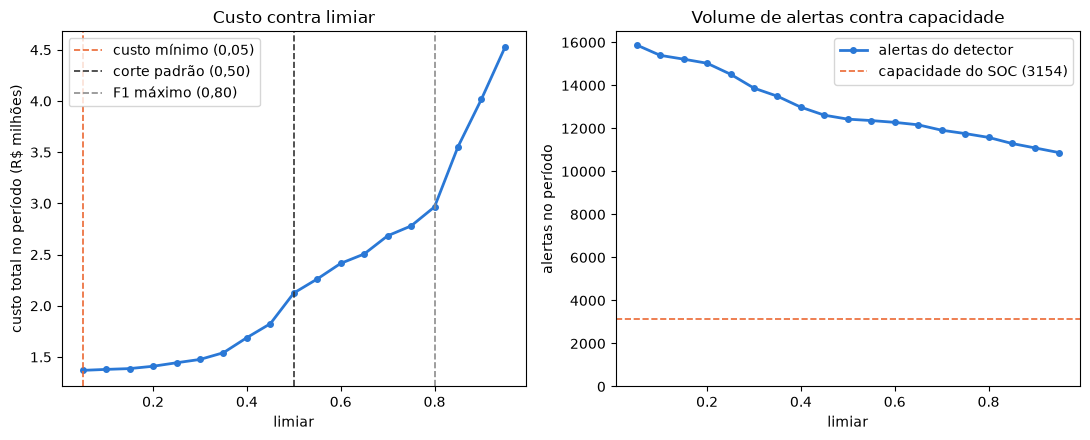

In [14]:
i_custo = tab_e['custo_total'].idxmin()
t_custo = float(tab_e.loc[i_custo, 'limiar'])
t_f1 = float(tab_e.loc[tab_e['F1'].idxmax(), 'limiar'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(tab_e['limiar'], tab_e['custo_total'] / 1e6, marker='o', markersize=4,
         color=COR_BENIGN, linewidth=2)
for t, cor, nome in [(t_custo, COR_ATAQUE, 'custo mínimo'),
                     (0.5, '0.2', 'corte padrão'),
                     (t_f1, '0.55', 'F1 máximo')]:
    ax1.axvline(t, color=cor, linestyle='--', linewidth=1.2, label=f'{nome} ({vg(t)})')
ax1.set_xlabel('limiar')
ax1.set_ylabel('custo total no período (R$ milhões)')
ax1.set_title('Custo contra limiar')
ax1.legend()

ax2.plot(tab_e['limiar'], tab_e['alertas'], marker='o', markersize=4,
         color=COR_BENIGN, linewidth=2, label='alertas do detector')
ax2.axhline(capacidade, color=COR_ATAQUE, linestyle='--', linewidth=1.2,
            label=f'capacidade do SOC ({capacidade})')
ax2.set_ylim(0, None)
ax2.set_xlabel('limiar')
ax2.set_ylabel('alertas no período')
ax2.set_title('Volume de alertas contra capacidade')
ax2.legend()
plt.tight_layout()
plt.show()

In [15]:
idx = [int(tab_e.index[tab_e['limiar'] == t][0]) for t in [0.5, t_f1, t_custo]]
resumo = tab_e.loc[idx, ['limiar', 'FP', 'FN', 'alertas', 'recall', 'F1', 'custo_total']].copy()
resumo.index = ['corte 0,5', f'F1 máximo ({vg(t_f1)})', f'custo mínimo ({vg(t_custo)})']
display(resumo.round(4))

c_05, c_f1, c_min = resumo['custo_total'].tolist()
print(f'economia do custo mínimo sobre o corte 0,5: R$ {brl(c_05 - c_min)}')
print(f'economia do custo mínimo sobre o F1 máximo: R$ {brl(c_f1 - c_min)}')

,limiar,FP,FN,alertas,recall,F1,custo_total
"corte 0,5",0.50,592,847,12429,0.9332,0.9427,2124604.0
"F1 máximo (0,80)",0.80,82,1186,11580,0.9065,0.9477,2965984.0
"custo mínimo (0,05)",0.05,3721,530,15875,0.9582,0.8512,1369652.0


economia do custo mínimo sobre o corte 0,5: R$ 754.952
economia do custo mínimo sobre o F1 máximo: R$ 1.596.332


In [16]:
# o limiar de custo mínimo cabe na capacidade? algum outro cabe?
print(f'alertas no limiar de custo mínimo: {int(resumo["alertas"].iloc[2])} '
      f'contra capacidade de {capacidade}')
print(f'menor volume da grade: {int(tab_e["alertas"].min())} alertas, no limiar '
      f'{vg(float(tab_e.loc[tab_e["alertas"].idxmin(), "limiar"]))}')

fina = varrer_limiares(y_te, p_te, np.round(np.arange(0, 1.02, 0.01), 2),
                       custo_fp=CUSTO_FP, custo_fn=CUSTO_FN)
cabem = fina[fina['alertas'] <= capacidade]
print(f'limiares de 0,00 a 1,01 que cabem na capacidade: {len(cabem)}')
display(cabem[['limiar', 'TP', 'FP', 'FN', 'alertas', 'recall', 'custo_total']].round(4))

nao_nulo = fina[fina['alertas'] > 0]
i_fino = fina['custo_total'].idxmin()
print(f'menor volume não nulo possível: {int(nao_nulo["alertas"].min())} alertas, no limiar '
      f'{vg(float(nao_nulo.loc[nao_nulo["alertas"].idxmin(), "limiar"]))}')
print(f'custo mínimo fora da grade do enunciado: limiar {vg(float(fina.loc[i_fino, "limiar"]))}, '
      f'R$ {brl(float(fina.loc[i_fino, "custo_total"]))} com '
      f'{int(fina.loc[i_fino, "alertas"])} alertas e recall {fina.loc[i_fino, "recall"]:.4f}')

print(f'detector perfeito, recall 1,0 e precisão 1,0: {int(y_te.sum())} alertas, '
      f'{y_te.sum() / capacidade:.1f} vezes a capacidade')

# de onde vem a fila: composição dos alertas no limiar de custo mínimo
comp = label_te[p_te >= t_custo].value_counts()
familia = comp[comp.index.str.contains('PortScan|DoS')].sum()
print(f'varredura e negação de serviço no limiar {vg(t_custo)}: {int(familia)} de '
      f'{int(comp.sum())} alertas, {familia / comp.sum():.1%} da fila')

alertas no limiar de custo mínimo: 15875 contra capacidade de 3154
menor volume da grade: 10875 alertas, no limiar 0,95
limiares de 0,00 a 1,01 que cabem na capacidade: 1


,limiar,TP,FP,FN,alertas,recall,custo_total
101,1.01,0,0,12684,0,0.0,31710000.0


menor volume não nulo possível: 10230 alertas, no limiar 1,00
custo mínimo fora da grade do enunciado: limiar 0,00, R$ 226.284 com 31541 alertas e recall 1.0000
detector perfeito, recall 1,0 e precisão 1,0: 12684 alertas, 4.0 vezes a capacidade
varredura e negação de serviço no limiar 0,05: 9910 de 15875 alertas, 62.4% da fila


In [17]:
# sensibilidade: e se o falso negativo custar cinco vezes mais?
tab_e5 = varrer_limiares(y_te, p_te, LIMIARES, custo_fp=CUSTO_FP, custo_fn=5 * CUSTO_FN)
i5 = tab_e5['custo_total'].idxmin()

sens = pd.DataFrame(
    {'limiar de custo mínimo': [vg(t_custo), vg(float(tab_e5.loc[i5, 'limiar']))],
     'custo nesse limiar': [brl(c_min), brl(float(tab_e5.loc[i5, 'custo_total']))],
     'custo no corte 0,5': [brl(c_05),
                            brl(float(tab_e5.loc[tab_e5['limiar'] == 0.5, 'custo_total'].iloc[0]))],
     'custo no F1 máximo': [brl(c_f1),
                            brl(float(tab_e5.loc[tab_e5['limiar'] == t_f1, 'custo_total'].iloc[0]))]},
    index=[f'C_FN = {brl(CUSTO_FN)}', f'C_FN = {brl(5 * CUSTO_FN)}'])
display(sens)
print(f'razão entre os custos: {CUSTO_FN // CUSTO_FP} para 1, '
      f'e {5 * CUSTO_FN // CUSTO_FP} para 1 no cenário cinco vezes maior')

,limiar de custo mínimo,custo nesse limiar,"custo no corte 0,5",custo no F1 máximo
C_FN = 2.500,"0,05",1.369.652,2.124.604,2.965.984
C_FN = 12.500,"0,05",6.669.652,10.594.604,14.825.984


razão entre os custos: 208 para 1, e 1041 para 1 no cenário cinco vezes maior


### Pergunta E.1

O limiar de custo mínimo é 0,05, com R$ 1.369.652 no período do teste. Ele economiza R$ 754.952 em relação ao corte 0,5, que custa R$ 2.124.604, e R$ 1.596.332 em relação ao limiar de F1 máximo, que custa R$ 2.965.984.

A explicação está na assimetria dos preços. Um falso negativo custa 208 vezes um falso positivo, então vale a pena aceitar até 208 alarmes falsos para evitar um ataque que passa. O corte 0,5 deixa passar 847 ataques e o de F1 máximo deixa passar 1.186, contra 530 no limiar de 0,05. Os falsos positivos que esses cortes economizam, 3.129 e 3.639, não chegam perto de compensar.

O custo cresce de forma monótona com o limiar em toda a grade, ou seja o mínimo está na borda inferior e não num vale. Uma varredura de 0,00 a 1,01 mostra que o ótimo verdadeiro é 0,00, alertar em todos os fluxos, com R$ 226.284 e recall 1,0. O limiar de F1 máximo aponta na direção contrária porque o F1 trata os dois erros como equivalentes.

### Pergunta E.2

Não respeita. O limiar de custo mínimo gera 15.875 alertas, cinco vezes a capacidade de 3.154, que é 10% dos 31.541 fluxos do período de teste. Nenhum limiar da grade cabe: o menor volume é 10.875, no corte 0,95, onde a precisão já é 1,0.

Não existe menor custo dentro da capacidade, porque não existe limiar dentro da capacidade. O menor volume não nulo possível é 10.230 alertas, no corte 1,00.

O limite não é do modelo. Um detector perfeito, com recall 1,0 e precisão 1,0, emitiria exatamente um alerta para cada um dos 12.684 ataques do teste, quatro vezes a capacidade do time. Nenhum limiar, modelo ou treino resolve isso, porque nesse ponto todos os alertas que sobram são verdadeiros e nenhum pode ser descartado. A restrição de 10% foi pensada para um ambiente em que o ataque é raro, e a prevalência deste recorte é 0,4021.

Por isso a decisão troca de lado. Ela sai do algoritmo e passa a ser de gestão: aumentar o SOC. Eu recomendaria o limiar de 0,05, que é o de custo mínimo, e levaria a capacidade ao gestor como o gargalo que precisa de investimento, não como um parâmetro a ser ajustado. Subir o corte para caber na fila não resolve, porque o excedente que hoje é alerta viraria ataque não detectado, ao custo de R$ 2.500 cada. Enquanto o time não cresce, as saídas paliativas são automatizar a triagem e agrupar os alertas por campanha, já que 9.910 dos 15.875 alertas, 62,4% da fila, são varredura e negação de serviço, famílias em que muitos fluxos pertencem ao mesmo evento.

Se o custo do falso negativo for cinco vezes maior, R$ 12.500, a recomendação não muda. O limiar de custo mínimo continua em 0,05, agora com R$ 6.669.652, e a razão entre os custos passa de 208 para 1.041. A distância para os outros cortes aumenta: o corte 0,5 passa a custar R$ 10.594.604 e o de F1 máximo R$ 14.825.984. O argumento da capacidade fica mais forte ainda, porque cada alerta não triado passa a valer cinco vezes mais.

---

## f) Validação: o número que você reportaria

In [18]:
# validação cruzada estratificada de 5 folds sobre todo o dataset limpo
X_todo, y_todo = flx_limpo[features_limpas], flx_limpo['ataque']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)

pr_folds, p_oof = [], np.zeros(len(y_todo))
for i_tr, i_te in skf.split(X_todo, y_todo):
    rf_cv = RandomForestClassifier(n_estimators=100, random_state=RS, n_jobs=-1)
    rf_cv.fit(X_todo.iloc[i_tr], y_todo.iloc[i_tr])
    p_fold = rf_cv.predict_proba(X_todo.iloc[i_te])[:, 1]
    p_oof[i_te] = p_fold
    pr_folds.append(average_precision_score(y_todo.iloc[i_te], p_fold))

pr_folds = np.array(pr_folds)
display(pd.DataFrame({'PR-AUC': [pr_folds.mean(), pr_auc],
                      'desvio dos folds': [pr_folds.std(), np.nan],
                      'fluxos avaliados': [len(y_todo), len(y_te)]},
                     index=['validação cruzada (5 folds)', 'split temporal']).round(4))
print('PR-AUC por fold:', np.round(pr_folds, 4).tolist())
print(f'a validação cruzada supera o split temporal em {pr_folds.mean() - pr_auc:.4f}')

,PR-AUC,desvio dos folds,fluxos avaliados
validação cruzada (5 folds),0.9980,0.0004,105097
split temporal,0.9731,NaN,31541


PR-AUC por fold: [0.9985, 0.9984, 0.9976, 0.9978, 0.9979]
a validação cruzada supera o split temporal em 0.0250


In [19]:
# o mesmo contraste na classe difícil, usando as previsões fora do fold
eh_bot_todo = (flx_limpo['Label'] == CLASSE_DIFICIL).values
rec_bot_cv = (p_oof[eh_bot_todo] >= 0.5).mean()
rec_bot_temporal = (p_te[eh_bot] >= 0.5).mean()

display(pd.DataFrame({'fluxos': [int(eh_bot_todo.sum()), int(eh_bot.sum())],
                      f'recall de {CLASSE_DIFICIL} em 0,5': [rec_bot_cv, rec_bot_temporal]},
                     index=['validação cruzada (5 folds)', 'split temporal']).round(4))
print(f'{CLASSE_DIFICIL} com pontuação 0 na validação cruzada: '
      f'{(p_oof[eh_bot_todo] == 0).mean():.1%}')
print(f'{CLASSE_DIFICIL} com pontuação 0 no split temporal: {(p_te[eh_bot] == 0).mean():.1%}')

,fluxos,"recall de Bot em 0,5"
validação cruzada (5 folds),1971,0.9731
split temporal,592,0.1554


Bot com pontuação 0 na validação cruzada: 0.0%
Bot com pontuação 0 no split temporal: 75.8%


### Pergunta F.1

A validação cruzada é a estimativa otimista: PR-AUC de 0,9980, com desvio de 0,0004 entre os folds, contra 0,9731 do split temporal. A diferença é de 0,0250.

O motivo é o embaralhamento. A validação cruzada estratificada sorteia as linhas sem olhar a ordem de captura, então cada fold treina com fluxos do começo e do fim da mesma campanha de ataque. O modelo aprende com informação do futuro e, na hora de prever, reencontra fluxos quase idênticos aos que já viu. O desvio de 0,0004 entre os cinco folds confirma o diagnóstico: eles são recortes aleatórios da mesma distribuição, então não há nada que os diferencie.

O número que descreve o que o SOC vai ver na semana que vem é o do split temporal, 0,9731. Ele treina no passado e testa no futuro, que é a única coisa que a operação faz. A distância de 0,0250 entre as duas estimativas é uma medida do drift dentro do próprio dataset.

A classe difícil mostra o tamanho real do problema. No Roteiro 2, o recall do Bot caiu de 0,96 no split aleatório para 0,16 no temporal, e aqui o mesmo contraste se repete: nas previsões fora do fold da validação cruzada o recall do Bot é 0,9731, contra 0,1554 no split temporal. Nenhum fluxo de Bot recebe pontuação 0 na validação cruzada, enquanto no split temporal 75,8% recebem. Ou seja, a PR-AUC global cai 0,0250 enquanto o recall da classe difícil cai 0,8177. A média é dominada pelas classes volumosas e quase não registra o colapso. Levar a validação cruzada ao gestor esconderia justamente o caso que a operação mais precisa enxergar.